# GHSL — settlement classes (GHS-SMOD)

GHS-SMOD is the **Degree of Urbanisation** settlement model — a *categorical* grid (urban centre / clusters / rural / water). It has no tiled resolution, so this downloads the whole-globe 1 km file (~100 MB) **once** and crops it to a Portugal-sized AOI. The output carries a class colour table and a `.legend.json` sidecar, and reprojection uses nearest-neighbour so class codes are never blended.

> The code cells are marked `NBVAL_SKIP` so the docs test suite does not re-download the global file; the saved outputs below are real.

In [1]:
# NBVAL_SKIP
import json
import tempfile
from pathlib import Path

from earthlens import EarthLens

out = tempfile.mkdtemp()
paths = EarthLens(
    data_source='ghsl',
    variables=['GHS_SMOD'],
    start='2020-01-01',
    end='2020-12-31',
    aoi=[-9.6, 36.9, -6.0, 42.2],
    path=out,
).download(progress_bar=False)
paths

2026-05-29 00:33:27 | INFO | pyramids.base.config | Logging is configured.


2026-05-29 00:33:27 | WARNING | pyramids.base.config.gdal | GDAL[6] Band data type of Int16 cannot represent the specified NoData value of nan


2026-05-29 00:33:49.888 | WARNING  | earthlens.ghsl.backend:_localise:652 - GHSL: could not embed the colour table for GHS_SMOD (OptionalPackageDoesNotExist); the legend sidecar is still written.


[WindowsPath('C:/Users/main/AppData/Local/Temp/claude/tmpud9xdbxl/GHS_SMOD_E2020_1km_epsg4326.tif')]

The categorical raster ships a class-code → label legend sidecar:

In [2]:
# NBVAL_SKIP
legend = json.loads(paths[0].with_suffix('.legend.json').read_text())
legend

{'30': 'Urban Centre',
 '23': 'Dense Urban Cluster',
 '22': 'Semi-dense Urban Cluster',
 '21': 'Suburban / Peri-urban',
 '13': 'Rural Cluster',
 '12': 'Low Density Rural',
 '11': 'Very Low Density Rural',
 '10': 'Water'}

Plot the settlement classes with the GHSL legend colours:

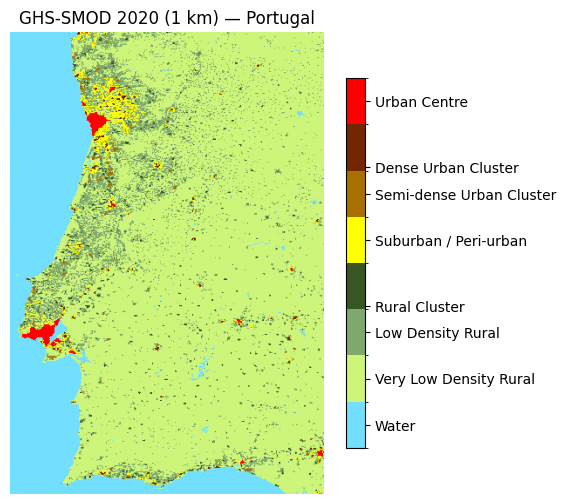

In [3]:
import matplotlib.pyplot as plt

# NBVAL_SKIP
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap
from pyramids.dataset import Dataset

from earthlens.ghsl import Catalog

prod = Catalog().get('GHS_SMOD')
arr = np.asarray(Dataset.read_file(str(paths[0])).read_array(), dtype='float32')
arr = arr[0] if arr.ndim == 3 else arr
codes = sorted(prod.legend)
cmap = ListedColormap([prod.colors[c] for c in codes])
norm = BoundaryNorm([c - 0.5 for c in codes] + [codes[-1] + 0.5], cmap.N)
plt.figure(figsize=(6, 6))
im = plt.imshow(arr, cmap=cmap, norm=norm)
cbar = plt.colorbar(im, ticks=codes, shrink=0.8)
cbar.ax.set_yticklabels([prod.legend[c] for c in codes])
plt.title('GHS-SMOD 2020 (1 km) — Portugal')
plt.axis('off')
plt.show()